In [43]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rakeshkapilavai/extrovert-vs-introvert-behavior-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\yamaw\.cache\kagglehub\datasets\rakeshkapilavai\extrovert-vs-introvert-behavior-data\versions\2


In [44]:
import pandas as pd
import os

files = os.listdir(path)
print(files)

['personality_datasert.csv', 'personality_dataset.csv']


In [45]:
df = pd.read_csv(os.path.join(path, 'personality_dataset.csv'))

# 中身を確認
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [46]:
df.shape

(2900, 8)

In [47]:
df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [48]:
# 欠損値がある行を削除した新しいデータフレームを作る
df_clean = df.dropna().copy()


# 前後のサイズを比較
print(f"元のデータ数：{len(df)}件")
print(f"削除後のデータ数：{len(df_clean)}件")

# 正確の割合が崩れていないか確認
print("【削除後の性格分布】")
print(df_clean["Personality"].value_counts(normalize=True)) 


元のデータ数：2900件
削除後のデータ数：2477件
【削除後の性格分布】
Personality
Extrovert    0.514332
Introvert    0.485668
Name: proportion, dtype: float64


In [49]:
# 文字列のカラムを指定
cat_features = ["Stage_fear", "Drained_after_socializing", "Personality"]

# 辞書を使って置換
mapping = {
    "Yes": 1, "No": 0,
    "Extrovert": 1, "Introvert": 0
}

# 変更実行
for col in cat_features:
    df_clean[col] = df_clean[col].map(mapping)

# 確認
df_clean.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,1
1,9.0,1,0.0,0.0,1,0.0,3.0,0
2,9.0,1,1.0,2.0,1,5.0,2.0,0
3,0.0,0,6.0,7.0,0,14.0,8.0,1
4,3.0,0,9.0,4.0,0,8.0,5.0,1


In [50]:
rename_dict = {
    "Time_spent_Alone": "一人で過ごす時間",
    "Stage_fear": "人前への苦手意識",
    "Social_event_attendance": "イベント参加頻度",
    "Going_outside": "外出頻度",
    "Drained_after_socializing": "交流後の疲労感",
    "Friends_circle_size": "友達の数",
    "Post_frequency": "SNS投稿頻度",
    "Personality": "性格"
}

df_clean = df_clean.rename(columns=rename_dict)

df_clean.head()

,一人で過ごす時間,人前への苦手意識,イベント参加頻度,外出頻度,交流後の疲労感,友達の数,SNS投稿頻度,性格
0,4.0,0,4.0,6.0,0,13.0,5.0,1
1,9.0,1,0.0,0.0,1,0.0,3.0,0
2,9.0,1,1.0,2.0,1,5.0,2.0,0
3,0.0,0,6.0,7.0,0,14.0,8.0,1
4,3.0,0,9.0,4.0,0,8.0,5.0,1


In [51]:
df_clean.isnull().sum()

一人で過ごす時間    0
人前への苦手意識    0
イベント参加頻度    0
外出頻度        0
交流後の疲労感     0
友達の数        0
SNS投稿頻度     0
性格          0
dtype: int64

In [52]:
from sklearn.model_selection import train_test_split

X = df_clean.drop("性格", axis=1)
y = df_clean["性格"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"学習用データの数：{len(X_train)}件")
print(f"テスト用データの数：{len(X_test)}件")

学習用データの数：1981件
テスト用データの数：496件


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# モデルの作成
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 学習
model.fit(X_train, y_train)

# 予測
y_pred = model.predict(X_test)

# 正解率
accuracy_score = accuracy_score(y_test, y_pred)
print(f"ランダムフォレストの正解率：{accuracy_score * 100:.2f}%")

ランダムフォレストの正解率：90.73%


In [54]:
from sklearn.metrics import classification_report

# 精度の評価レポートを表示
report_dict = classification_report(y_test, y_pred, target_names=["内向型", "外向型"], output_dict=True)

report_df = pd.DataFrame(report_dict)

display(report_df.round(3))

,内向型,外向型,accuracy,macro avg,weighted avg
precision,0.898,0.917,0.907,0.908,0.907
recall,0.920,0.894,0.907,0.907,0.907
f1-score,0.909,0.905,0.907,0.907,0.907
support,250.000,246.000,0.907,496.000,496.000


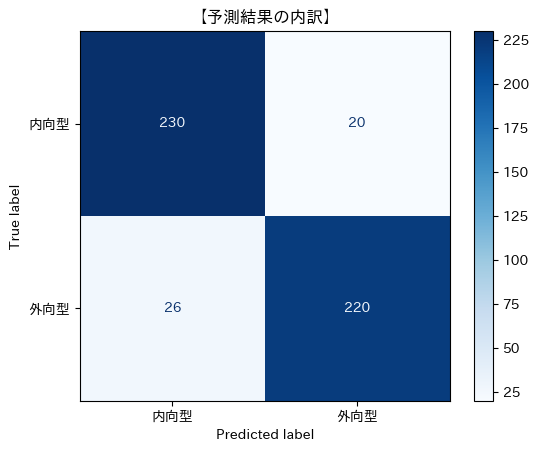

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import japanize_matplotlib

# 混合行列を表示
disp = ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=["内向型", "外向型"],
    cmap=plt.cm.Blues
)
plt.title("【予測結果の内訳】")
plt.show()

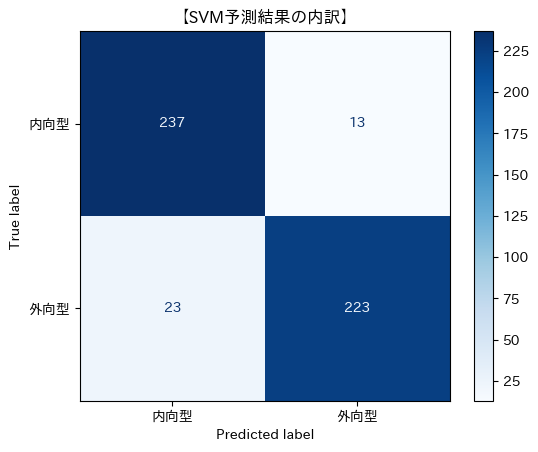

In [56]:
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# SVCでモデル作成
svm_model = SVC(kernel="linear", probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# 学習
svm_model.fit(X_train, y_train)

# 混合行列を表示する
disp = ConfusionMatrixDisplay.from_estimator(
    svm_model, X_test, y_test,
    display_labels=["内向型", "外向型"],
    cmap=plt.cm.Blues,
)

plt.title("【SVM予測結果の内訳】")
plt.show()


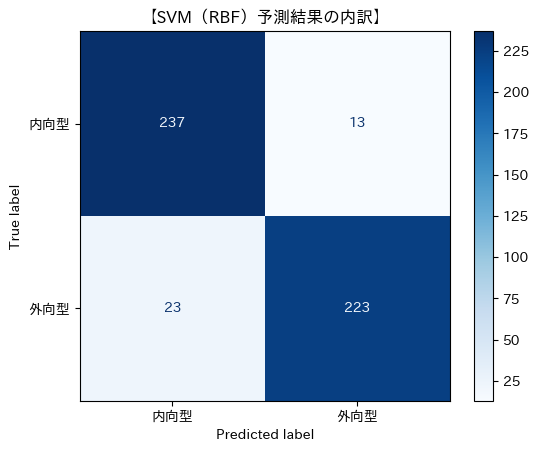

In [57]:
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# kernel="rbf"に変えてみる
svm_rbf = SVC(kernel="rbf", probability=True, random_state=42)
svm_rbf.fit(X_train, y_train)

# 混合行列を表示
disp = ConfusionMatrixDisplay.from_estimator(
    svm_rbf, X_test, y_test,
    display_labels=["内向型", "外向型"],
    cmap=plt.cm.Blues
)

plt.title("【SVM（RBF）予測結果の内訳】")
plt.show()

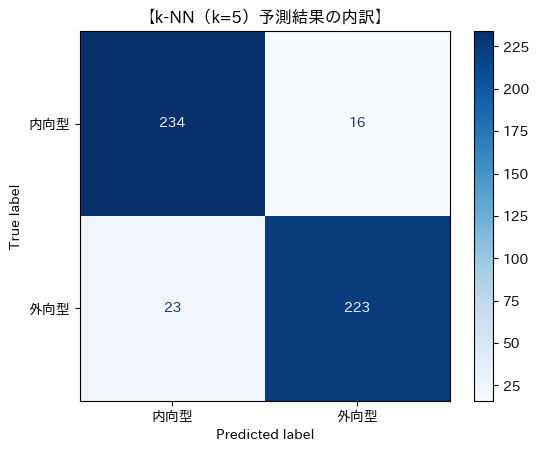

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# モデルの作成
knn_model = KNeighborsClassifier(n_neighbors=5)

# 学習
knn_model.fit(X_train, y_train)

# 混合行列を表示
disp = ConfusionMatrixDisplay.from_estimator(
    knn_model, X_test, y_test,
    display_labels=["内向型", "外向型"],
    cmap=plt.cm.Blues
)

plt.title("【k-NN（k=5）予測結果の内訳】")
plt.show()

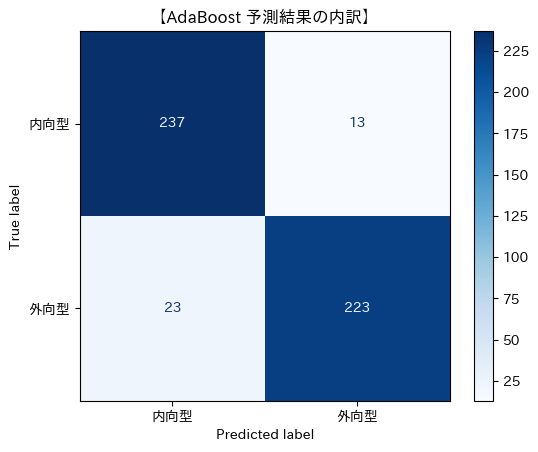

In [59]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# モデルの作成
# n_estimators=100は、「100このモデルを順番に作って弱点を補強する」
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

# 学習
ada_model.fit(X_train, y_train)

# 混合行列を表示
disp = ConfusionMatrixDisplay.from_estimator(
    ada_model, X_test, y_test,
    display_labels=["内向型", "外向型"],
    cmap=plt.cm.Blues
)

plt.title("【AdaBoost 予測結果の内訳】")
plt.show()

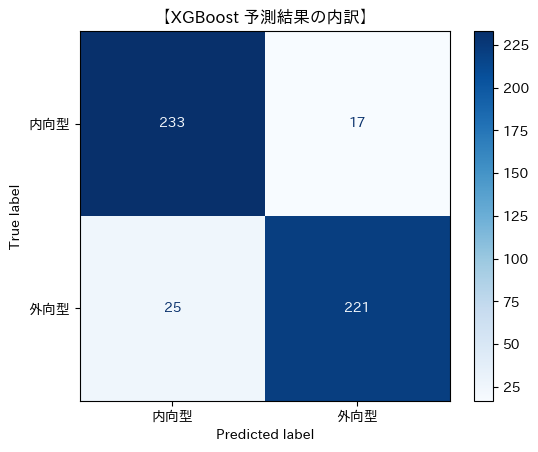

In [60]:
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# モデルの作成
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

# 学習
xgb_model.fit(X_train, y_train)

# 混合行列を表示
disp = ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_test, y_test,
    display_labels=["内向型", "外向型"],
    cmap=plt.cm.Blues
)

plt.title("【XGBoost 予測結果の内訳】")
plt.show()

[LightGBM] [Info] Number of positive: 1028, number of negative: 953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 62
[LightGBM] [Info] Number of data points in the train set: 1981, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.518930 -> initscore=0.075756
[LightGBM] [Info] Start training from score 0.075756


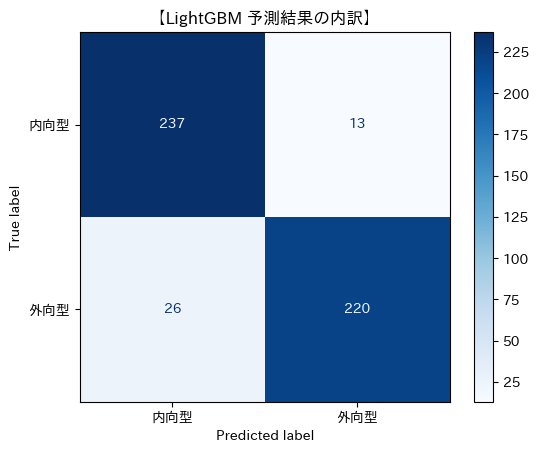

In [61]:
import lightgbm as lgb
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# モデルの作成
lgbm_model = lgb.LGBMClassifier(random_state=42)

# 学習
lgbm_model.fit(X_train, y_train)

# 混合行列を表示
disp = ConfusionMatrixDisplay.from_estimator(
    lgbm_model, X_test, y_test,
    display_labels=["内向型", "外向型"],
    cmap=plt.cm.Blues
)

plt.title("【LightGBM 予測結果の内訳】")
plt.show()

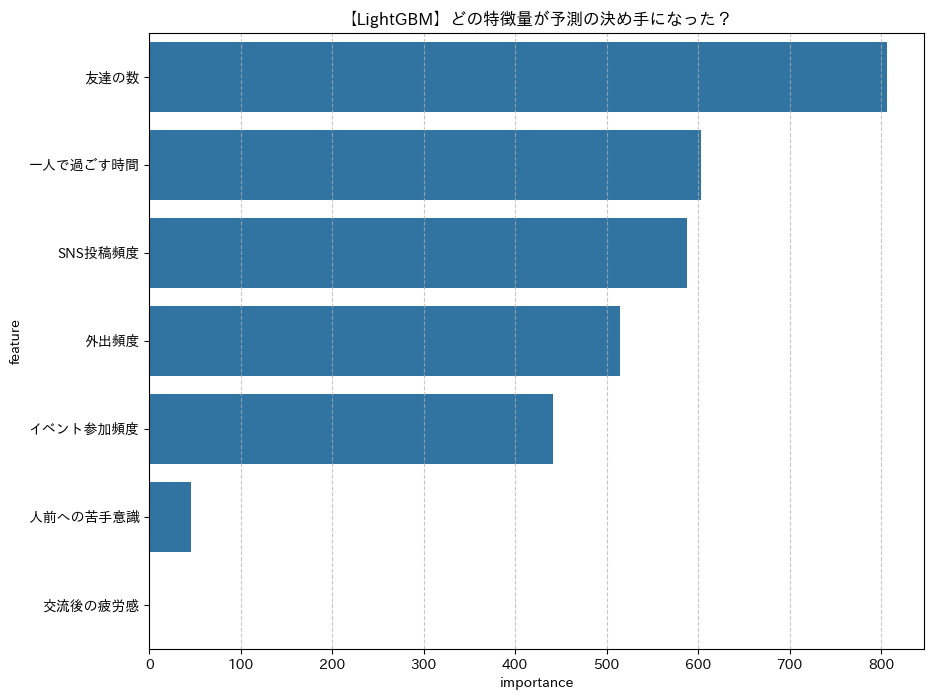

In [62]:
import pandas as pd
import seaborn as sns

# 重要度を取得してDataFrameにまとめる
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values(ascending=False, by="importance")

# グラフで表示
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=feature_importance, )
plt.title("【LightGBM】どの特徴量が予測の決め手になった？")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

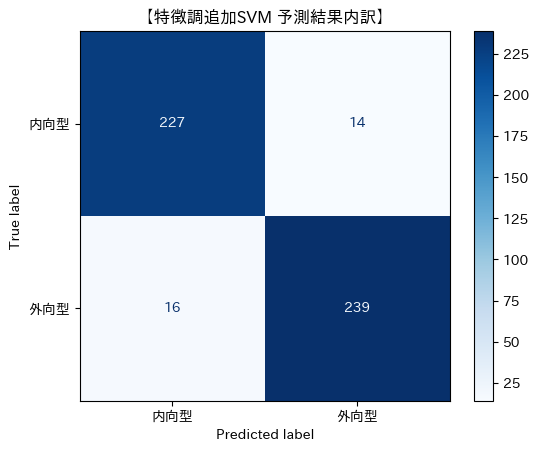

In [63]:
X_new = X.copy()

#友達は多いけど一人の時間も長いという「矛盾」を数値化 
X_new["社交ギャップ"] = X_new["友達の数"] / (X_new["一人で過ごす時間"] + 1)

# 人前が苦手なのに外出頻度が高いという「頑張り」を数値化
X_new["無理してる指標"] = X_new["外出頻度"] + X_new["人前への苦手意識"]

# データを再分割
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_new, y, test_size=0.2, random_state=42, stratify=y
)

# バランスの良かったSVM（RBF）で学習
svm_new = SVC(kernel="rbf", random_state=42)
svm_new.fit(X_train_n, y_train_n)

# 混合行列を表示
disp = ConfusionMatrixDisplay.from_estimator(
    svm_new, X_test_n, y_test_n,
    display_labels=["内向型", "外向型"],
    cmap=plt.cm.Blues,
)
plt.title("【特徴調追加SVM 予測結果内訳】")
plt.show()